# HematIn — OCR + Expense Classifier (EasyOCR)

---

## Arsitektur Pipeline

```
Gambar Struk
    │
    ▼  preprocess_image()     grayscale · resize · denoise · threshold · deskew
    │
    ▼  run_ocr()              PaddleOCR pretrained (bukan custom CRNN)
    │
    ▼  parse_receipt()        raw OCR lines → items[], qty, unit_price, line_total
    │
    ▼  extract_fields()       merchant · total_expense · distinct_item_count · total_qty
    │
    ▼  classify_receipt()     TF multi-input Classifier (text + tabular)
    │
    ▼
Kategori + Confidence
(confidence < threshold → "unknown")
```

---

## Arsitektur Classifier

```
text_input (string)                tabular_input (float32 × 5)
    │                                      │
    ▼ TextVectorization                    ▼
    ▼ Embedding(64)                    Dense(64, ReLU)
    ▼ BiLSTM(64, return_sequences)     BatchNorm
    ▼ AttentionLayer *                 Dense(32, ReLU)
    │                                      │
    └──────────── Concatenate ─────────────┘
                        │
                   Dense(128, ReLU)
                   Dropout(0.3)
                   Dense(N_CLASSES, softmax)
```
`*` = Custom Layer

---

## Custom Components (Classifier)

| Komponen | Tipe | Fungsi |
|---|---|---|
| `AttentionLayer` | Custom Layer | Bahdanau self-attention atas output BiLSTM |
| `FocalLoss` | Custom Loss | Class imbalance — Lin et al. 2017 |
| `PerCategoryMetricsCallback` | Custom Callback | F1 per kategori tiap epoch |

---

## Catatan Desain

- **OCR**: EasyOCR pretrained — tidak ada training OCR dari nol
- **CORD**: untuk parser logic, field extraction, synthetic sample — bukan OCR training
- **Item parsing**: raw OCR lines → regex (`JANGAN` lewat `clean_text`)
- **clean_text**: hanya untuk teks input ke classifier TF
- **Confidence threshold**: kategori = `"unknown"` jika confidence < threshold
- **Offline mode**: set `PADDLE_MODEL_BASE` di `config.py` untuk Kaggle no-internet

## Dataset
- https://www.kaggle.com/datasets/lonelvino/cord-1000/data
- https://www.kaggle.com/datasets/herdinthorikn/capstonedataset


## 0. Install & Import

In [5]:
%pip install -q easyocr
%pip install -q tensorflow>=2.13 scikit-learn opencv-python-headless matplotlib pandas shapely


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os, re, sys, json, random, shutil
from pathlib import Path
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

if "." not in sys.path:
    sys.path.insert(0, ".")

print(f"TensorFlow : {tf.__version__}")
print(f"Python     : {sys.version.split()[0]}")
print(f"GPU        : {[g.name for g in tf.config.list_physical_devices('GPU')] or 'CPU-only'}")


TensorFlow : 2.19.0
Python     : 3.12.12
GPU        : ['/physical_device:GPU:0', '/physical_device:GPU:1']


## 1. Modul

### 1.1 config.py

In [7]:
%%writefile config.py
"""
config.py — Konfigurasi terpusat HematIn v5
Semua konstanta, path, dan fungsi utilitas didefinisikan di sini.
"""
import re
import numpy as np
from pathlib import Path
from datetime import datetime

# ── Paths ─────────────────────────────────────────────────────────────────────
CORD_DIR  = Path("/kaggle/input/datasets/lonelvino/cord-1000/CORD/CORD")
CSV_PATH  = Path("/kaggle/input/datasets/herdinthorikn/capstonedataset/pengeluaran_model2.csv")

MODEL_DIR      = Path("/kaggle/input/datasets/herdinthorikn/capstonedataset")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CLF_MODEL_PATH ="/kaggle/working/models/classifier.keras"
VOCAB_PATH     = "/kaggle/working/models/vectorizer_vocab.json"

# Path model PaddleOCR lokal (offline mode)
# Isi path Kaggle Dataset berisi model paddle, kosongkan untuk mode online
PADDLE_MODEL_BASE = ""  # contoh: "/kaggle/input/paddle-ocr-models"

# ── Classifier ────────────────────────────────────────────────────────────────
CATEGORIES = [
    "Makanan/Minuman", "Hiburan", "Kesehatan",
    "Belanja", "Transportasi", "Pendidikan",
    "Tagihan/Utilitas", "Investasi", "Keuangan", "Lain-lain"
]
CAT2IDX     = {c: i for i, c in enumerate(CATEGORIES)}
NUM_CLASSES = len(CATEGORIES)

CAT_REMAP = {
    "Sosial"   : "Lain-lain",
    "Olahraga" : "Kesehatan",
}

TEXT_VOCAB_SZ    = 6000
MAX_TEXT_LEN     = 40
EMBED_DIM        = 64
TAB_FEATURES     = 5   # total/100k, log_total, is_large, avg_price, item_count

CLF_BATCH_SIZE   = 32
CLF_EPOCHS       = 60
CLF_LR           = 1e-3
VALIDATION_SPLIT = 0.20

# ── Inference ─────────────────────────────────────────────────────────────────
CONFIDENCE_THRESHOLD = 0.40   # di bawah ini → category = "unknown"

# ── TensorBoard ───────────────────────────────────────────────────────────────
RUN_TIME   = datetime.now().strftime("%Y%m%d-%H%M%S")
TB_LOG_DIR = f"/kaggle/working/tensorboard_logs/{RUN_TIME}"


# ── Text Preprocessing ────────────────────────────────────────────────────────
def clean_text(text: str) -> str:
    """
    Pembersihan teks kanonik — HANYA untuk input classifier TF.
    JANGAN gunakan untuk parsing item dari OCR lines.

    Langkah:
        1. Guard None / NaN → ""
        2. Lowercase
        3. Ganti non-alfanumerik & non-spasi dengan spasi
        4. Collapse whitespace, strip
    """
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ── Tabular Features ──────────────────────────────────────────────────────────
def build_tabular_features(
    total: float,
    avg_price: float = 0.0,
    item_count: int  = 1,
) -> np.ndarray:
    """
    5 fitur tabular dari data receipt.
    Harus konsisten antara training dan inference.
    """
    return np.array([
        total / 100_000,
        np.log1p(total / 1_000),
        1.0 if total > 100_000 else 0.0,
        min(avg_price / 100_000, 10.0),
        min(float(item_count) / 10.0, 1.0),
    ], dtype=np.float32)


Overwriting config.py


### 1.2 custom_components.py — AttentionLayer · FocalLoss · PerCategoryMetricsCallback

In [8]:
%%writefile custom_components.py
"""
custom_components.py — Custom TF/Keras components untuk Classifier HematIn

OCR menggunakan PaddleOCR pretrained.

Komponen:
    AttentionLayer             -- Custom Layer  (Classifier)
    FocalLoss                  -- Custom Loss   (Classifier)
    PerCategoryMetricsCallback -- Custom Callback (Classifier)
"""
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score
import config


# ── AttentionLayer ────────────────────────────────────────────────────────────
@tf.keras.utils.register_keras_serializable(package="HematIn")
class AttentionLayer(tf.keras.layers.Layer):
    """
    Bahdanau-style self-attention atas output BiLSTM.

    Rumus:
        e_t  = tanh(W * h_t + b)
        a_t  = softmax(v^T * e_t)
        ctx  = sum(a_t * h_t)

    Kata kunci seperti "goreng", "bioskop", "laptop" sangat informatif
    untuk klasifikasi. Attention memungkinkan model fokus pada kata tersebut.
    """

    def __init__(self, units: int = 64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.supports_masking = True

    def build(self, input_shape):
        self.W = tf.keras.layers.Dense(self.units, use_bias=True, activation="tanh")
        self.v = tf.keras.layers.Dense(1, use_bias=False)
        self.W.build(input_shape)
        self.v.build((input_shape[0], input_shape[1], self.units))
        super().build(input_shape)

    def call(self, sequence, mask=None):
        score = self.v(self.W(sequence))
        if mask is not None:
            mask = tf.cast(mask, tf.float32)
            score += (1.0 - tf.expand_dims(mask, -1)) * -1e9
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * sequence, axis=1)
        return context

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"units": self.units})
        return cfg


# ── FocalLoss ─────────────────────────────────────────────────────────────────
@tf.keras.utils.register_keras_serializable(package="HematIn")
class FocalLoss(tf.keras.losses.Loss):
    """
    Focal Loss — Lin et al. 2017.

    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)

    Dataset pengeluaran tidak seimbang (Makanan/Minuman >> kategori lain).
    Focal loss menekan kontribusi loss dari sampel mudah agar model
    lebih fokus pada kategori yang sulit.

    Args:
        gamma : focusing parameter (default=2.0)
        alpha : weighting factor   (default=0.25)
    """

    def __init__(self, gamma: float = 2.0, alpha: float = 0.25,
                 name: str = "focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred       = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce           = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        p_t          = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_weight = self.alpha * tf.pow(1.0 - p_t, self.gamma)
        return tf.reduce_mean(focal_weight * ce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"gamma": self.gamma, "alpha": self.alpha})
        return cfg


# ── PerCategoryMetricsCallback ────────────────────────────────────────────────
class PerCategoryMetricsCallback(tf.keras.callbacks.Callback):
    """
    Log F1-score per kategori pengeluaran setiap epoch.

    - Menyimpan histori F1 di self.history untuk diplot setelah training.
    - Menambahkan 'val_macro_f1' ke logs Keras → dipakai EarlyStopping.
    - Kompatibel dengan TensorBoard melalui logs dict.

    Args:
        val_dataset : tf.data.Dataset validasi → (x_dict, y_onehot)
        categories  : list nama kategori
    """

    def __init__(self, val_dataset, categories=None):
        super().__init__()
        self.val_dataset = val_dataset
        self.categories  = categories or config.CATEGORIES
        self.history     = {c: [] for c in self.categories}
        self.history["macro_f1"] = []

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_true_all, y_pred_all = [], []

        for x_batch, y_batch in self.val_dataset:
            probs = self.model(x_batch, training=False).numpy()
            y_pred_all.append(np.argmax(probs, axis=1))
            y_true_all.append(np.argmax(y_batch.numpy(), axis=1))

        y_true = np.concatenate(y_true_all)
        y_pred = np.concatenate(y_pred_all)

        f1_per_class = f1_score(
            y_true, y_pred,
            average=None,
            labels=list(range(len(self.categories))),
            zero_division=0,
        )
        support  = np.bincount(y_true, minlength=len(self.categories))
        macro_f1 = float(np.mean(f1_per_class))

        print(f"\n  [Epoch {epoch + 1}] Per-Category F1:")
        print(f"  {'Category':<26}| {'F1':>6} | Support")
        print("  " + "-" * 44)
        for i, cat in enumerate(self.categories):
            f1  = float(f1_per_class[i]) if i < len(f1_per_class) else 0.0
            sup = int(support[i])
            self.history[cat].append(f1)
            print(f"  {cat:<26}| {f1:>6.4f} | {sup:>7}")
        print("  " + "-" * 44)
        print(f"  {'Macro F1':<26}| {macro_f1:>6.4f} |")

        logs["val_macro_f1"] = macro_f1
        self.history["macro_f1"].append(macro_f1)


# ── CUSTOM_OBJECTS registry ───────────────────────────────────────────────────
CUSTOM_OBJECTS = {
    "AttentionLayer" : AttentionLayer,
    "FocalLoss"      : FocalLoss,
}


Overwriting custom_components.py


### 1.3 image_preprocessing.py

In [9]:
%%writefile image_preprocessing.py
"""
image_preprocessing.py — Preprocessing gambar struk sebelum OCR

Pipeline:
    1. Load gambar (path / np.ndarray)
    2. Resize jika terlalu besar
    3. Denoise (bilateral filter)
    4. CLAHE untuk kontras lokal
    5. Grayscale
    6. Adaptive threshold (untuk debug/analisis)
    7. Optional deskew
    8. Return: BGR (untuk PaddleOCR) + gray + binary + skew angle
"""

from pathlib import Path
from typing import Union, Optional
import cv2
import numpy as np


def _estimate_skew_angle(binary: np.ndarray) -> float:
    """
    Estimasi sudut kemiringan dari binary image menggunakan minAreaRect.
    Return sudut dalam derajat.
    """
    coords = np.column_stack(np.where(binary > 0))
    if len(coords) < 50:
        return 0.0
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
    return angle


def _apply_deskew(img_bgr: np.ndarray, angle: float) -> np.ndarray:
    """Rotasi gambar BGR sebesar angle derajat dengan padding REPLICATE."""
    if abs(angle) < 0.3:
        return img_bgr
    h, w = img_bgr.shape[:2]
    M    = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img_bgr, M, (w, h),
                          flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_REPLICATE)


def preprocess_image(
    img_source: Union[str, Path, np.ndarray],
    target_width: int = 960,
    deskew: bool      = True,
    clahe_clip: float = 2.0,
) -> dict:
    """
    Preprocessing lengkap gambar struk untuk OCR.

    Args:
        img_source   : path file atau np.ndarray (BGR / grayscale)
        target_width : resize jika lebar melebihi nilai ini (px)
        deskew       : apakah koreksi kemiringan dijalankan
        clahe_clip   : clip limit CLAHE

    Returns:
        dict berisi:
            'bgr'    : np.ndarray (H,W,3) uint8 — input ke PaddleOCR
            'gray'   : np.ndarray (H,W)   uint8 — untuk debug
            'binary' : np.ndarray (H,W)   uint8 — untuk debug
            'skew'   : float — sudut koreksi yang diterapkan (derajat)
    """
    # 1. Load
    if isinstance(img_source, (str, Path)):
        img = cv2.imread(str(img_source), cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"Gambar tidak ditemukan: {img_source}")
    else:
        img = img_source.copy()
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # 2. Resize
    h, w = img.shape[:2]
    if w > target_width:
        scale = target_width / w
        img   = cv2.resize(img, None, fx=scale, fy=scale,
                           interpolation=cv2.INTER_AREA)

    # 3. Denoise (bilateral — edge-preserving)
    img = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

    # 4. CLAHE pada channel L (LAB)
    lab     = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=(8, 8))
    img     = cv2.cvtColor(cv2.merge([clahe.apply(l), a, b]), cv2.COLOR_LAB2BGR)

    # 5. Grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 6. Adaptive Threshold
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=15,
        C=8,
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # 7. Deskew
    skew_angle = 0.0
    if deskew:
        inv        = cv2.bitwise_not(binary)
        skew_angle = _estimate_skew_angle(inv)
        if abs(skew_angle) > 0.3:
            img    = _apply_deskew(img, skew_angle)
            gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            binary = cv2.adaptiveThreshold(
                gray, 255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY, 15, 8
            )

    return {"bgr": img, "gray": gray, "binary": binary, "skew": skew_angle}


Writing image_preprocessing.py


### 1.4 ocr_pipeline.py

> **Online vs Offline**
>
> - **Online** (default): PaddleOCR download model otomatis saat pertama run — butuh internet sekali.
> - **Offline**: isi `PADDLE_MODEL_BASE` di `config.py` dengan path model lokal.
>   Lihat panduan setup offline di bawah.


In [10]:
%%writefile ocr_pipeline.py
"""
ocr_pipeline.py — OCR menggunakan PaddleOCR (pretrained)

Mode operasi:
    ONLINE  : PaddleOCR auto-download model saat pertama run (butuh internet)
    OFFLINE : Model dimuat dari path lokal

Setup offline di Kaggle:
    1. Jalankan sekali dengan Internet ON → model ter-cache, zip, upload sebagai Dataset
    2. Tambahkan dataset ke notebook, isi PADDLE_MODEL_BASE di config.py
    3. get_ocr_engine() akan otomatis mendeteksi dan memakai model lokal

Struktur direktori model offline yang diharapkan:
    <PADDLE_MODEL_BASE>/
        det/en_PP-OCRv3_det_infer/      (inference.pdmodel, inference.pdiparams)
        rec/en_PP-OCRv4_rec_infer/      (inference.pdmodel, inference.pdiparams)
        cls/ch_ppocr_mobile_v2.0_cls_infer/  (inference.pdmodel, inference.pdiparams)
"""

from pathlib import Path
from typing import Union, Optional
import numpy as np

_OCR_ENGINE = None

# KODE LAMA
# _DET_MODEL_NAME = "en_PP-OCRv3_det_infer"
# _REC_MODEL_NAME = "en_PP-OCRv4_rec_infer"
# _CLS_MODEL_NAME = "ch_ppocr_mobile_v2.0_cls_infer"


def _find_model_dir(base: Path, subdir: str, model_name: str) -> Optional[str]:
    """
    Cari direktori model di base/subdir/model_name.
    Return path string jika ada dan tidak kosong, None jika tidak.
    """
    candidate = base / subdir / model_name
    if candidate.exists() and any(candidate.iterdir()):
        return str(candidate)
    return None


def get_ocr_engine(
    lang           : str           = "en",
    use_gpu        : bool          = False,
    model_base_dir : Optional[str] = None,
):
    global _OCR_ENGINE
    if _OCR_ENGINE is not None:
        return _OCR_ENGINE

    import easyocr
    import config

    model_dir = None
    if model_base_dir:
        model_dir = model_base_dir
    elif getattr(config, "PADDLE_MODEL_BASE", ""):
        model_dir = config.PADDLE_MODEL_BASE

    kwargs = {
        "lang_list" : ["en", "id"],
        "gpu"       : use_gpu,
        "verbose"   : False,
    }
    if model_dir:
        kwargs["model_storage_directory"] = model_dir
        print(f"[EasyOCR] Mode OFFLINE — model dari {model_dir}")
    else:
        print("[EasyOCR] Mode ONLINE — download model (butuh internet)")

    _OCR_ENGINE = easyocr.Reader(**kwargs)
    print("[EasyOCR] Engine siap")
    return _OCR_ENGINE


def reset_ocr_engine():
    """Reset singleton — berguna untuk switch mode saat testing."""
    global _OCR_ENGINE
    _OCR_ENGINE = None
    print("[PaddleOCR] Engine direset")


def run_ocr(
    img_source     : Union[str, Path, np.ndarray],
    ocr_engine     = None,
    min_confidence : float = 0.50,
) -> list[dict]:
    engine    = ocr_engine or get_ocr_engine()
    img_input = str(img_source) if isinstance(img_source, (str, Path)) else img_source

    result = engine.readtext(img_input, detail=1, paragraph=False)

    lines = []
    for (bbox, text, conf) in result:
        text = text.strip()
        if conf < min_confidence or not text:
            continue
        ys       = [pt[1] for pt in bbox]
        y_center = float(np.mean(ys))
        lines.append({
            "text"       : text,
            "confidence" : conf,
            "bbox"       : bbox,
            "y_center"   : y_center,
        })

    lines.sort(key=lambda x: x["y_center"])
    return lines


def ocr_to_lines(ocr_results: list[dict]) -> list[str]:
    """Konversi hasil PaddleOCR ke list string baris saja."""
    return [item["text"] for item in ocr_results]


Writing ocr_pipeline.py


#### Setup Offline PaddleOCR di Kaggle

**Langkah 1** — Download & zip model (jalankan sekali dengan Internet ON):


In [11]:
# Jalankan cell ini SEKALI dengan Internet ON.
# EasyOCR menyimpan model di ~/.EasyOCR/model/

from pathlib import Path
from ocr_pipeline import get_ocr_engine, reset_ocr_engine
import zipfile

reset_ocr_engine()
get_ocr_engine(use_gpu=False)   # trigger download en + id
print("Model berhasil didownload")

CACHE_DIR  = Path.home() / ".EasyOCR" / "model"
EASYOCR_ZIP = "/kaggle/working/easyocr_models.zip"

with zipfile.ZipFile(EASYOCR_ZIP, "w", zipfile.ZIP_DEFLATED) as zf:
    for fp in CACHE_DIR.rglob("*"):
        if fp.is_file():
            zf.write(fp, fp.relative_to(CACHE_DIR))
            print(f"  Packed: {fp.name}")

size_mb = Path(EASYOCR_ZIP).stat().st_size / 1024**2
print(f"Zip siap: {EASYOCR_ZIP}  ({size_mb:.1f} MB)")
print("Langkah selanjutnya:")
print("  1. Download easyocr_models.zip dari Kaggle output")
print("  2. Upload sebagai Kaggle Dataset baru (misal: 'easyocr-models')")
print("  3. Tambahkan dataset ke notebook ini")
print("  4. Set PADDLE_MODEL_BASE = '/kaggle/input/easyocr-models' di config.py")

[PaddleOCR] Engine direset
[EasyOCR] Mode ONLINE — download model (butuh internet)
[EasyOCR] Engine siap
Model berhasil didownload
  Packed: english_g2.pth
  Packed: craft_mlt_25k.pth
  Packed: latin_g2.pth
Zip siap: /kaggle/working/easyocr_models.zip  (100.7 MB)
Langkah selanjutnya:
  1. Download easyocr_models.zip dari Kaggle output
  2. Upload sebagai Kaggle Dataset baru (misal: 'easyocr-models')
  3. Tambahkan dataset ke notebook ini
  4. Set PADDLE_MODEL_BASE = '/kaggle/input/easyocr-models' di config.py


**Langkah 2** — Setelah dataset ditambahkan ke notebook, ubah `config.py`:

```python
PADDLE_MODEL_BASE = "/kaggle/input/easy-ocr-models"
```

`get_ocr_engine()` akan otomatis deteksi model lokal dan tidak download apapun.
```


### 1.5 receipt_parser.py

In [12]:
%%writefile receipt_parser.py
"""
receipt_parser.py — Parser terstruktur untuk struk belanja

Parsing dilakukan dari RAW OCR lines (bukan clean_text).
Output JSON-friendly dan tidak bergantung pada state notebook.

Fungsi:
    parse_number()    -- string angka IDR → float
    extract_merchant()-- estimasi nama toko
    extract_total()   -- cari total transaksi
    parse_item_line() -- satu baris → {name, qty, unit_price, line_total}
    parse_receipt()   -- raw OCR lines → structured receipt dict
    extract_fields()  -- wrapper lengkap untuk classifier + FastAPI output
"""

import re
from typing import Optional


# ── Konstanta keyword ─────────────────────────────────────────────────────────
TOTAL_KEYWORDS  = {"total", "jumlah", "subtotal", "tagihan",
                   "bayar", "grand", "amount", "tunai", "cash"}

SKIP_KEYWORDS   = {"diskon", "discount", "pajak", "tax", "ppn",
                   "kasir", "telp", "npwp", "wifi", "member",
                   "thank", "terima kasih", "struk", "item"}

HEADER_KEYWORDS = {"jl.", "jalan", "no.", "telp", "fax",
                   "www.", "http", "npwp"}

# Pola item: NAMA  QTY x UNIT_PRICE  LINE_TOTAL
# Contoh: "Nasi Goreng  2 x 15.000  30.000"
_PATTERN_QTY_X = re.compile(
    r'^(.+?)\s+(\d{1,3})\s*[xX×]\s*([\d.,]+)\s+([\d.,]+)\s*$'
)
# Pola: NAMA  QTY  UNIT_PRICE  LINE_TOTAL (empat kolom)
_PATTERN_4COL = re.compile(
    r'^(.+?)\s+(\d{1,3})\s+(\d[\d.,]+)\s+(\d[\d.,]+)\s*$'
)
# Pola: NAMA  LINE_TOTAL (dua kolom)
_PATTERN_2COL = re.compile(
    r'^(.+?)\s{2,}(\d[\d.,]{2,})\s*$'
)
# Angka harga (4+ digit)
_PRICE_RE = re.compile(r'\b(\d[\d.,]{3,})\b')

# ── Fungsi utilitas ───────────────────────────────────────────────────────────

def _has_price(line: str) -> bool:
    """Bedakan harga asli vs product code (misal: 6001-, J0o2-)"""
    for m in _PRICE_RE.finditer(line):
        if m.end() < len(line) and line[m.end()] == '-':
            continue
        return True
    return False


def _strip_product_code(name: str) -> str:
    """Hapus prefix product code seperti 'J0o2-', '1001-', '6001-'"""
    return re.sub(r'^[A-Za-z0-9]{2,8}-\s*', '', name).strip()

def parse_number(raw: str) -> float:
    """
    Konversi string angka IDR ke float.

    Contoh:
        "15.000"    → 15000.0  (titik = separator ribuan IDR)
        "15,000"    → 15000.0
        "15.000,50" → 15000.5  (IDR format lengkap)
        "15000"     → 15000.0
    """
    raw = raw.strip()
    raw = re.sub(r'\s+', '', raw)
    # IDR: titik ribuan, koma desimal — "15.000,50"
    if re.match(r'^\d{1,3}(\.\d{3})+(,\d+)?$', raw):
        raw = raw.replace('.', '').replace(',', '.')
    # Koma ribuan saja — "15,000"
    elif re.match(r'^\d{1,3}(,\d{3})+$', raw):
        raw = raw.replace(',', '')
    else:
        raw = re.sub(r'[^\d.]', '', raw)
        parts = raw.split('.')
        if len(parts) > 2:
            raw = ''.join(parts[:-1]) + '.' + parts[-1]
    try:
        return float(raw)
    except ValueError:
        return 0.0


def extract_merchant(lines: list[str]) -> str:
    """
    Estimasi nama merchant dari beberapa baris pertama.
    Skip baris yang murni angka atau mengandung keyword header.
    """
    for line in lines[:5]:
        clean = line.strip()
        if len(clean) < 4:
            continue
        lower = clean.lower()
        if any(kw in lower for kw in HEADER_KEYWORDS):
            continue
        if re.match(r'^[\d\s.,/:-]+$', clean):
            continue
        return clean
    return ""


def extract_total(lines: list[str]) -> float:
    for i, line in enumerate(reversed(lines)):
        idx  = len(lines) - 1 - i
        lower = line.lower()
        has_kw  = any(kw in lower for kw in TOTAL_KEYWORDS)
        nums    = _PRICE_RE.findall(line)

        # Keyword + angka di baris yang sama
        if has_kw and nums:
            val = max(parse_number(n) for n in nums)
            if val > 0:
                return val

        # Keyword tapi angka di baris berikutnya (1-2 baris ke bawah)
        if has_kw and not nums:
            for j in range(1, 3):
                if idx + j < len(lines):
                    next_nums = _PRICE_RE.findall(lines[idx + j])
                    if next_nums:
                        val = max(parse_number(n) for n in next_nums)
                        if val > 0:
                            return val

    # Fallback: angka terbesar dari 5 baris terakhir
    for line in reversed(lines[-5:]):
        nums = _PRICE_RE.findall(line)
        if nums:
            val = max(parse_number(n) for n in nums)
            if val > 0:
                return val

    return 0.0


def parse_item_line(line: str) -> Optional[dict]:
    """
    Parse satu baris menjadi item receipt.

    Returns:
        dict dengan key: name, qty, unit_price, line_total
        None jika baris tidak bisa diparse sebagai item
    """
    line = line.strip()
    if not line or len(line) < 3:
        return None

    lower = line.lower()
    if any(kw in lower for kw in TOTAL_KEYWORDS | SKIP_KEYWORDS | HEADER_KEYWORDS):
        return None
    if not _PRICE_RE.search(line):
        return None

    # Pola 1: QTY x UNIT = TOTAL
    m = _PATTERN_QTY_X.match(line)
    if m:
        name       = m.group(1).strip()
        qty        = int(m.group(2))
        unit_price = parse_number(m.group(3))
        line_total = parse_number(m.group(4))
        if name and line_total > 0:
            return {"name": _strip_product_code(name), "qty": qty,
                    "unit_price": unit_price, "line_total": line_total}

    # Pola 2: NAMA  QTY  UNIT  TOTAL
    m = _PATTERN_4COL.match(line)
    if m:
        name       = m.group(1).strip()
        qty        = int(m.group(2))
        unit_price = parse_number(m.group(3))
        line_total = parse_number(m.group(4))
        if (name and line_total > 0 and qty > 0
                and abs(line_total - qty * unit_price) / max(line_total, 1) < 0.20):
            return {"name": _strip_product_code(name), "qty": qty,
                    "unit_price": unit_price, "line_total": line_total}

    # Pola 3: NAMA  TOTAL (fallback)
    m = _PATTERN_2COL.match(line)
    if m:
        name       = m.group(1).strip()
        line_total = parse_number(m.group(2))
        if name and line_total > 0 and len(name) >= 3:
            return {"name": _strip_product_code(name), "qty": 1,
                    "unit_price": line_total, "line_total": line_total}
    return None

def _preprocess_lines(lines: list[str]) -> list[str]:
    """
    Dua pass:
    1. Gabung teks yang terpotong antar baris (misal: 'Plastic' + 'Bag')
    2. Gabung baris nama-item + baris harga menjadi satu baris
    """
    # Pass 1: gabung dua baris teks tanpa angka berurutan
    merged = []
    i = 0
    while i < len(lines):
        line  = lines[i].strip()
        lower = line.lower()
        is_text = not _has_price(line) and bool(re.search(r'[a-zA-Z]', line))
        is_skip = any(kw in lower for kw in TOTAL_KEYWORDS | SKIP_KEYWORDS)

        if is_text and not is_skip and i + 1 < len(lines):
            nxt       = lines[i + 1].strip()
            nxt_lower = nxt.lower()
            nxt_text = not _has_price(nxt) and bool(re.search(r'[a-zA-Z]', nxt))
            nxt_skip  = any(kw in nxt_lower for kw in TOTAL_KEYWORDS | SKIP_KEYWORDS)
            if nxt_text and not nxt_skip:
                merged.append(line + ' ' + nxt)
                i += 2
                continue

        merged.append(line)
        i += 1

    # Pass 2: gabung baris nama + baris angka berikutnya
    result = []
    i = 0
    while i < len(merged):
        line      = merged[i].strip()
        lower     = line.lower()
        has_price = _has_price(line)
        has_text  = bool(re.search(r'[a-zA-Z]', line))
        is_skip   = any(kw in lower for kw in TOTAL_KEYWORDS | SKIP_KEYWORDS)

        if has_text and not has_price and not is_skip and i + 1 < len(merged):
            nxt      = merged[i + 1].strip()
            nxt_nums = _has_price(nxt.replace(' ', ''))
            nxt_only_num = bool(re.match(r'^[\d\s.,]+$', nxt)) and nxt_nums
            if nxt_only_num:
                result.append(line + '  ' + nxt.replace(' ', ''))
                i += 2
                continue

        result.append(line)
        i += 1

    return result

def parse_receipt(raw_lines: list[str]) -> dict:
    """
    Parse list raw OCR lines menjadi structured receipt dict.

    Args:
        raw_lines : list[str] dari ocr_to_lines() — RAW, belum clean_text

    Returns:
        dict berisi:
            merchant            : str
            items               : list[dict] {name, qty, unit_price, line_total}
            total_expense       : float
            distinct_item_count : int
            total_qty           : int
            avg_item_price      : float
            raw_lines           : list[str]
    """
    lines = [l.strip() for l in raw_lines if l.strip()]
    merchant      = extract_merchant(lines)
    total_expense = extract_total(lines)
    lines = _preprocess_lines(lines)

    # Parse semua item
    items = []
    for line in lines:
        item = parse_item_line(line)
        if item:
            items.append(item)

    # Deduplicate berdasarkan nama (gabungkan qty dan line_total)
    deduped: dict[str, dict] = {}
    for it in items:
        key = it["name"].lower()
        if key in deduped:
            deduped[key]["qty"]        += it["qty"]
            deduped[key]["line_total"] += it["line_total"]
        else:
            deduped[key] = dict(it)
    items = list(deduped.values())

    distinct_item_count = len(items)
    total_qty           = sum(it["qty"] for it in items)
    sum_items           = sum(it["line_total"] for it in items)

    if total_expense == 0.0 and sum_items > 0:
        total_expense = sum_items

    avg_item_price = (total_expense / distinct_item_count
                      if distinct_item_count > 0 else total_expense)

    return {
        "merchant"           : merchant,
        "items"              : items,
        "total_expense"      : total_expense,
        "distinct_item_count": distinct_item_count,
        "total_qty"          : total_qty,
        "avg_item_price"     : avg_item_price,
        "raw_lines"          : lines,
    }


def extract_fields(raw_lines: list[str]) -> dict:
    """
    Wrapper extract_fields() — output lengkap untuk classifier + FastAPI.

    PENTING: raw_lines harus berupa OCR lines mentah.
    clean_text dipanggil di sini, satu kali, hanya untuk teks classifier.

    Returns:
        dict JSON-friendly berisi semua field receipt + fitur untuk classifier
    """
    import config

    receipt = parse_receipt(raw_lines)

    # Gabungkan nama item → clean_text untuk classifier
    # Ini satu-satunya tempat clean_text dipanggil pada teks OCR
    item_text = " ".join(it["name"] for it in receipt["items"])
    if not item_text:
        item_text = " ".join(receipt["raw_lines"][:5])
    clf_text = config.clean_text(item_text)

    tab = config.build_tabular_features(
        total      = receipt["total_expense"],
        avg_price  = receipt["avg_item_price"],
        item_count = receipt["distinct_item_count"],
    ).tolist()

    return {
        "items"              : receipt["items"],
        "distinct_item_count": receipt["distinct_item_count"],
        "total_qty"          : receipt["total_qty"],
        "total_expense"      : receipt["total_expense"],
        "avg_item_price"     : receipt["avg_item_price"],
        "clf_text"           : clf_text,
        "tab_features"       : tab,
        "raw_lines"          : receipt["raw_lines"],
    }


Writing receipt_parser.py


### 1.6 classifier_model.py

In [13]:
%%writefile classifier_model.py
"""
classifier_model.py — Multi-input Expense Classifier (TF Functional API)

Arsitektur:
    Text branch   : TextVectorization → Embedding(64) → BiLSTM(64) → AttentionLayer
    Tabular branch: Dense(64) → BatchNorm → Dense(32)
    Fusion        : Concatenate → Dense(128) → Dropout(0.3) → Dense(N, softmax)

Custom components:
    AttentionLayer             (Custom Layer)
    FocalLoss                  (Custom Loss)
    PerCategoryMetricsCallback (Custom Callback)
"""

import numpy as np
import pandas as pd
import tensorflow as tf

import config
from config import build_tabular_features, clean_text, CATEGORIES, CAT2IDX, CAT_REMAP
from custom_components import AttentionLayer, FocalLoss, PerCategoryMetricsCallback, CUSTOM_OBJECTS


def build_classifier(text_vectorizer) -> tf.keras.Model:
    """
    Bangun multi-input expense classifier — TF Functional API.

    Args:
        text_vectorizer : TextVectorization yang sudah .adapt()

    Returns:
        tf.keras.Model siap compile
    """
    text_input    = tf.keras.Input(shape=(1,), dtype=tf.string, name="text")
    tabular_input = tf.keras.Input(shape=(config.TAB_FEATURES,),
                                   dtype=tf.float32, name="tabular")

    # Text branch
    x_t = text_vectorizer(text_input)
    x_t = tf.keras.layers.Embedding(
        input_dim  = config.TEXT_VOCAB_SZ + 2,
        output_dim = config.EMBED_DIM,
        mask_zero  = True,
        name       = "embedding",
    )(x_t)
    x_t = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.25),
        name="bilstm",
    )(x_t)
    x_t = tf.keras.layers.Dropout(0.2, name="dropout_text")(x_t)
    x_t = AttentionLayer(units=64, name="attention")(x_t)

    # Tabular branch
    x_b = tf.keras.layers.Dense(64, activation="relu", name="tab_d1")(tabular_input)
    x_b = tf.keras.layers.BatchNormalization(name="tab_bn")(x_b)
    x_b = tf.keras.layers.Dense(32, activation="relu", name="tab_d2")(x_b)

    # Fusion
    merged = tf.keras.layers.Concatenate(name="fusion")([x_t, x_b])
    x      = tf.keras.layers.Dense(128, activation="relu", name="dense_128")(merged)
    x      = tf.keras.layers.Dropout(0.3, name="dropout_fusion")(x)
    output = tf.keras.layers.Dense(
        config.NUM_CLASSES, activation="softmax", name="output"
    )(x)

    return tf.keras.Model(
        inputs  = [text_input, tabular_input],
        outputs = output,
        name    = "expense_classifier",
    )


def load_expense_csv(csv_path=config.CSV_PATH) -> pd.DataFrame:
    """
    Load dan bersihkan CSV pengeluaran.

    Returns:
        DataFrame: clean_text, total_pengeluaran, kategori
    """
    df = pd.read_csv(csv_path)
    print(f"  CSV dimuat      : {len(df)} baris")

    # Normalisasi nama kolom
    col_map = {}
    taken   = {}
    for col in df.columns:
        c = col.lower().strip()
        if c in ("deskripsi", "teks", "text", "keterangan", "nama", "nama_produk"):
            target = "nama_produk"
        elif c in ("kategori", "category", "label", "kelas"):
            target = "kategori"
        elif c in ("total", "jumlah", "nominal", "harga",
                   "amount", "total_rupiah", "total_pengeluaran"):
            target = "total_pengeluaran"
        else:
            continue
        if target not in taken:
            col_map[col] = target
            taken[target] = col
    df.rename(columns=col_map, inplace=True)

    # Filter
    for bad in ["salary", "no notes"]:
        mask = df.get("nama_produk", pd.Series(dtype=str)).str.lower().str.strip().eq(bad)
        df   = df[~mask]
    df["total_pengeluaran"] = pd.to_numeric(
        df.get("total_pengeluaran", 0), errors="coerce").fillna(0.0)
    df = df[df["total_pengeluaran"] > 0]
    df = df[df["nama_produk"].str.len() >= 3]

    df["kategori"]  = df["kategori"].str.strip().map(lambda c: config.CAT_REMAP.get(c, c))
    df              = df[df["kategori"].isin(config.CATEGORIES)].copy()
    df["clean_text"] = df["nama_produk"].apply(clean_text)

    print(f"  Setelah cleaning: {len(df)} baris")
    print("  Distribusi kategori:")
    vc = df["kategori"].value_counts()
    for cat, cnt in vc.items():
        bar = "█" * (cnt * 25 // vc.max())
        print(f"    {cat:<28} {cnt:>5}  {bar}")

    return df[["clean_text", "total_pengeluaran", "kategori"]].reset_index(drop=True)


def make_clf_dataset(
    df         : pd.DataFrame,
    batch_size : int  = config.CLF_BATCH_SIZE,
    shuffle    : bool = True,
):
    """
    Buat tf.data.Dataset dari DataFrame expense.

    Returns:
        (dataset, texts_1d, y_onehot)
    """
    texts    = df["clean_text"].values.reshape(-1, 1)
    tabular  = np.array([
        build_tabular_features(row["total_pengeluaran"])
        for _, row in df.iterrows()
    ], dtype=np.float32)
    labels   = df["kategori"].map(config.CAT2IDX).values
    y_onehot = tf.keras.utils.to_categorical(labels, config.NUM_CLASSES).astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices(
        ({"text": texts, "tabular": tabular}, y_onehot)
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(df), 2048), seed=42)
    return (ds.batch(batch_size).prefetch(tf.data.AUTOTUNE),
            df["clean_text"].values,
            y_onehot)


Writing classifier_model.py


### 1.7 pipeline.py

In [14]:
%%writefile pipeline.py
"""
pipeline.py — Full end-to-end inference pipeline HematIn v5

Fungsi modular (FastAPI-ready):
    preprocess_image()  → image_preprocessing.py
    run_ocr()           → ocr_pipeline.py
    parse_receipt()     → receipt_parser.py
    extract_fields()    → receipt_parser.py
    classify_receipt()  → classifier TF
    analyze_receipt()   → full pipeline, JSON output

Semua output JSON-friendly. Tidak ada dependency pada global state notebook.
"""

from typing import Union
from pathlib import Path
import numpy as np
import tensorflow as tf

import config
from image_preprocessing import preprocess_image
from ocr_pipeline import run_ocr, get_ocr_engine, ocr_to_lines
from receipt_parser import extract_fields
from custom_components import CUSTOM_OBJECTS


def classify_receipt(
    clf_text    : str,
    tab_features: list,
    clf_model   : tf.keras.Model,
) -> dict:
    """
    Klasifikasikan satu receipt menggunakan classifier TF.

    Args:
        clf_text     : teks yang sudah di-clean_text (dari extract_fields)
        tab_features : list 5 float (dari extract_fields["tab_features"])
        clf_model    : TF model yang sudah di-load

    Returns:
        dict berisi:
            category      : str   — "unknown" jika confidence < threshold
            confidence    : float
            all_probs     : dict  {category: prob}
            is_confident  : bool
    """
    text_input = tf.constant([[clf_text]], dtype=tf.string)
    tab_input  = np.array([tab_features], dtype=np.float32)

    probs      = clf_model.predict(
        {"text": text_input, "tabular": tab_input}, verbose=0
    )[0]

    best_idx   = int(np.argmax(probs))
    confidence = float(probs[best_idx])
    is_conf    = confidence >= config.CONFIDENCE_THRESHOLD
    category   = config.CATEGORIES[best_idx] if is_conf else "unknown"

    return {
        "category"    : category,
        "confidence"  : round(confidence, 4),
        "all_probs"   : {cat: round(float(p), 4)
                         for cat, p in zip(config.CATEGORIES, probs)},
        "is_confident": is_conf,
    }


def analyze_receipt(
    img_source   : Union[str, Path, np.ndarray],
    clf_model    : tf.keras.Model,
    ocr_engine   = None,
    deskew       : bool  = True,
    min_ocr_conf : float = 0.50,
) -> dict:
    """
    Full pipeline: gambar struk → JSON lengkap.

    Args:
        img_source   : path file atau np.ndarray BGR
        clf_model    : TF classifier model
        ocr_engine   : PaddleOCR instance (None → singleton)
        deskew       : aktifkan koreksi kemiringan
        min_ocr_conf : filter confidence OCR

    Returns:
        dict JSON-friendly:
            preprocessing : info preprocessing
            ocr_lines     : list raw OCR lines
            fields        : hasil extract_fields (tanpa raw_lines)
            classification: hasil classify_receipt
    """
    # 1. Preprocessing
    prep = preprocess_image(img_source, deskew=deskew)
    bgr  = prep["bgr"]

    # 2. OCR
    engine    = ocr_engine or get_ocr_engine()
    ocr_res   = run_ocr(bgr, engine, min_confidence=min_ocr_conf)
    raw_lines = ocr_to_lines(ocr_res)

    # 3. Extract fields (parse receipt + clean_text untuk classifier)
    fields = extract_fields(raw_lines)

    # 4. Classify
    clf_result = classify_receipt(
        clf_text     = fields["clf_text"],
        tab_features = fields["tab_features"],
        clf_model    = clf_model,
    )

    return {
        "preprocessing" : {
            "skew_corrected": round(prep["skew"], 2),
            "image_size"    : list(bgr.shape[:2]),
        },
        "ocr_lines"     : raw_lines,
        "ocr_count"     : len(raw_lines),
        "fields"        : {k: v for k, v in fields.items() if k != "raw_lines"},
        "classification": clf_result,
    }


Writing pipeline.py


In [15]:
import os, sys

for mod in ["receipt_parser", "pipeline", "config", "custom_components"]:
    pyc = f"/kaggle/working/__pycache__/{mod}.cpython-312.pyc"
    if os.path.exists(pyc):
        os.remove(pyc)
        print(f"Deleted: {pyc}")
    if mod in sys.modules:
        del sys.modules[mod]

from receipt_parser import extract_fields
from pipeline import classify_receipt
print("Import selesai")

Deleted: /kaggle/working/__pycache__/config.cpython-312.pyc
Import selesai


## 2. Dataset

### 2.1 CORD-1000 — Memahami Struktur Struk

CORD dipakai untuk:
- Memahami pola item, qty, harga dari struk nyata
- Generate synthetic training samples untuk classifier
- **Bukan** untuk training OCR dari nol


In [16]:
import json as _json
from pathlib import Path
import config

CORD_BASE = Path(config.CORD_DIR)
cord_ok   = CORD_BASE.exists()

if not cord_ok:
    print(f"[WARN] CORD tidak ditemukan di {CORD_BASE}")
    print("       Synthetic samples dilewati — training tetap bisa jalan dari CSV.")
else:
    print(f"[OK] CORD ditemukan di {CORD_BASE}")


def load_cord_records(split: str) -> list:
    json_dir = CORD_BASE / split / "json"
    if not json_dir.exists():
        return []
    records = []
    for jf in sorted(json_dir.glob("*.json")):
        with open(jf, encoding="utf-8") as f:
            label = _json.load(f)
        words_flat = []
        for line in label.get("valid_line", []):
            for word in line.get("words", []):
                text = word.get("text", "").strip()
                if text:
                    words_flat.append({
                        "text"    : text,
                        "category": word.get("category", ""),
                    })
        records.append({
            "stem"     : jf.stem,
            "words"    : words_flat,
            "full_text": " ".join(w["text"] for w in words_flat),
        })
    return records


cord_data = {}
if cord_ok:
    print("\n[CORD] Memuat annotations...")
    for sp in ["train", "dev", "test"]:
        cord_data[sp] = load_cord_records(sp)
        n_words = sum(len(r["words"]) for r in cord_data[sp])
        print(f"  [{sp:5s}] {len(cord_data[sp]):4d} struk | {n_words:6d} kata")
    print(f"  Total : {sum(len(v) for v in cord_data.values())} struk")


[OK] CORD ditemukan di /kaggle/input/datasets/lonelvino/cord-1000/CORD/CORD

[CORD] Memuat annotations...
  [train]  800 struk |  19370 kata
  [dev  ]  100 struk |   2186 kata
  [test ]  100 struk |   2356 kata
  Total : 1000 struk


### 2.2 Generate Synthetic Training Samples dari CORD

In [17]:
from receipt_parser import parse_number
from config import clean_text

MENU_CATS  = {"menu.nm", "menu.sub_nm", "menu.etc"}
PRICE_CATS = {"menu.price", "menu.sub_price", "menu.unitprice"}
TOTAL_CATS = {"total.total_price", "total.cashprice"}

synthetic_samples = []

def extract_cord_sample(record: dict):
    menu_names, prices, total = [], [], 0.0
    for w in record["words"]:
        cat, text = w["category"], w["text"]
        if cat in MENU_CATS and len(text) >= 2:
            menu_names.append(text)
        elif cat in PRICE_CATS:
            val = parse_number(text)
            if val > 0:
                prices.append(val)
        elif cat in TOTAL_CATS:
            val = parse_number(text)
            if val > total:
                total = val

    if not menu_names:
        return None
    if total == 0 and prices:
        total = sum(prices)

    text = clean_text(" ".join(menu_names))
    if not text or len(text) < 3:
        return None

    return {
        "clean_text"        : text,
        "total_pengeluaran" : max(total, 5000.0),
        "kategori"          : "Makanan/Minuman",
    }


if cord_ok:
    for sp in cord_data:
        for rec in cord_data[sp]:
            s = extract_cord_sample(rec)
            if s:
                synthetic_samples.append(s)
    df_synthetic = pd.DataFrame(synthetic_samples)
    print(f"[Synthetic] {len(df_synthetic)} samples dari CORD")
    print(df_synthetic.head(5).to_string(index=False))
else:
    df_synthetic = pd.DataFrame(columns=["clean_text", "total_pengeluaran", "kategori"])
    print("[Synthetic] CORD tidak ada — df_synthetic kosong")


[Synthetic] 0 samples dari CORD
Empty DataFrame
Columns: []
Index: []


### 2.3 Load CSV + Gabungkan Dataset

In [18]:
from classifier_model import load_expense_csv

df_csv = None
try:
    df_csv = load_expense_csv(config.CSV_PATH)
    print(f"\n[CSV] {len(df_csv)} baris dimuat")
except Exception as e:
    print(f"[WARN] CSV gagal dimuat: {e}")

if df_csv is not None and len(df_synthetic) > 0:
    df_all = pd.concat([df_csv, df_synthetic], ignore_index=True)
    print(f"\n[Dataset Gabungan] {len(df_csv)} CSV + {len(df_synthetic)} CORD synthetic = {len(df_all)} total")
elif df_csv is not None:
    df_all = df_csv.copy()
    print(f"\n[Dataset] Hanya CSV: {len(df_all)} baris")
else:
    print("\n[WARN] Tidak ada data — membuat dummy dataset minimal untuk demo")
    df_all = pd.DataFrame({
        "clean_text"        : ["nasi goreng", "tiket bioskop", "laptop asus",
                               "deterjen rinso", "token pln", "grab motor"],
        "total_pengeluaran" : [25000, 75000, 8500000, 32000, 150000, 15000],
        "kategori"          : ["Makanan/Minuman", "Hiburan", "Belanja",
                               "Belanja", "Tagihan/Utilitas", "Transportasi"],
    })

print("\n[Distribusi final]:")
for cat, cnt in df_all["kategori"].value_counts().items():
    pct = cnt / len(df_all) * 100
    bar = "█" * int(pct / 2)
    print(f"  {cat:<28} {cnt:>5} ({pct:5.1f}%)  {bar}")


  CSV dimuat      : 9183 baris
  Setelah cleaning: 9160 baris
  Distribusi kategori:
    Makanan/Minuman               1978  █████████████████████████
    Tagihan/Utilitas              1622  ████████████████████
    Transportasi                  1314  ████████████████
    Kesehatan                     1164  ██████████████
    Belanja                        862  ██████████
    Pendidikan                     703  ████████
    Lain-lain                      423  █████
    Keuangan                       391  ████
    Hiburan                        372  ████
    Investasi                      331  ████

[CSV] 9160 baris dimuat

[Dataset] Hanya CSV: 9160 baris

[Distribusi final]:
  Makanan/Minuman               1978 ( 21.6%)  ██████████
  Tagihan/Utilitas              1622 ( 17.7%)  ████████
  Transportasi                  1314 ( 14.3%)  ███████
  Kesehatan                     1164 ( 12.7%)  ██████
  Belanja                        862 (  9.4%)  ████
  Pendidikan                     703 (  7

In [19]:
augment = pd.DataFrame([
    {"clean_text": "nasi goreng ayam geprek",    "total_pengeluaran": 25000,   "kategori": "Makanan/Minuman"},
    {"clean_text": "aqua indomie mie goreng",     "total_pengeluaran": 8500,    "kategori": "Makanan/Minuman"},
    {"clean_text": "kopi susu gula aren",         "total_pengeluaran": 28000,   "kategori": "Makanan/Minuman"},
    {"clean_text": "grab motor ojek online",      "total_pengeluaran": 18000,   "kategori": "Transportasi"},
    {"clean_text": "gojek gocar taksi online",    "total_pengeluaran": 35000,   "kategori": "Transportasi"},
    {"clean_text": "tiket bioskop film avengers", "total_pengeluaran": 75000,   "kategori": "Hiburan"},
    {"clean_text": "laptop asus vivobook",        "total_pengeluaran": 8500000, "kategori": "Belanja"},
    {"clean_text": "deterjen rinso sabun cuci",   "total_pengeluaran": 32000,   "kategori": "Belanja"},
    {"clean_text": "vitamin c suplemen kesehatan","total_pengeluaran": 55000,   "kategori": "Kesehatan"},
    {"clean_text": "token pln bayar listrik",     "total_pengeluaran": 150000,  "kategori": "Tagihan/Utilitas"},
    {"clean_text": "samsung galaxy smartphone",   "total_pengeluaran": 5000000, "kategori": "Belanja"},
])

df_all = pd.concat([df_all, augment], ignore_index=True)

### 2.4 Train / Val / Test Split

In [20]:
from classifier_model import make_clf_dataset

df_train, df_temp = train_test_split(
    df_all, test_size=0.30, random_state=SEED, stratify=df_all["kategori"]
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp["kategori"]
)

print(f"Train : {len(df_train):5d} baris")
print(f"Val   : {len(df_val):5d} baris")
print(f"Test  : {len(df_test):5d} baris")

train_ds, train_texts, train_y = make_clf_dataset(df_train, shuffle=True)
val_ds,   val_texts,   val_y   = make_clf_dataset(df_val,   shuffle=False)
test_ds,  test_texts,  test_y  = make_clf_dataset(df_test,  shuffle=False)


Train :  6419 baris
Val   :  1376 baris
Test  :  1376 baris


I0000 00:00:1779835385.319237      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779835385.325442      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 3. Training

### 3.1 Build Classifier

In [21]:
import importlib, sys

for mod_name in ["config", "custom_components", "classifier_model"]:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

import config
from custom_components import FocalLoss, PerCategoryMetricsCallback, CUSTOM_OBJECTS
from classifier_model  import build_classifier

tf.keras.backend.clear_session()

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens             = config.TEXT_VOCAB_SZ,
    output_mode            = "int",
    output_sequence_length = config.MAX_TEXT_LEN,
    standardize            = "lower_and_strip_punctuation",
)
vectorizer.adapt(train_texts)
print(f"Vocab size: {len(vectorizer.get_vocabulary())}")

clf_model = build_classifier(vectorizer)
clf_model.summary(line_length=80)


Vocab size: 1109


Model: "expense_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)     │ (None, 1)         │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ text_vectorization    │ (None, 40)        │           0 │ text[0][0]         │
│ (TextVectorization)   │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ embedding (Embedding) │ (None, 40, 64)    │     384,128 │ text_vectorizatio… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ not_equal (NotEqual)  │ (None, 40)        │           0 │ text_vectorizatio… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ tabular (InputLayer)  │ (None, 5)         │           0 │ -                  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bilstm                │ (None, 40, 128)   │      66,048 │ embedding[0][0],   │
│ (Bidirectional)       │                   │             │ not_equal[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ tab_d1 (Dense)        │ (None, 64)        │         384 │ tabular[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_text          │ (None, 40, 128)   │           0 │ bilstm[0][0]       │
│ (Dropout)             │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ tab_bn                │ (None, 64)        │         256 │ tab_d1[0][0]       │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ attention             │ (None, 128)       │       8,320 │ dropout_text[0][0… │
│ (AttentionLayer)      │                   │             │ not_equal[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ tab_d2 (Dense)        │ (None, 32)        │       2,080 │ tab_bn[0][0]       │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ fusion (Concatenate)  │ (None, 160)       │           0 │ attention[0][0],   │
│                       │                   │             │ tab_d2[0][0]       │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_128 (Dense)     │ (None, 128)       │      20,608 │ fusion[0][0]       │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_fusion        │ (None, 128)       │           0 │ dense_128[0][0]    │
│ (Dropout)             │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ output (Dense)        │ (None, 10)        │       1,290 │ dropout_fusion[0]… │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 483,114 (1.84 MB)

 Trainable params: 482,986 (1.84 MB)

 Non-trainable params: 128 (512.00 B)

### 3.2 Compile & Train

In [22]:
from config import TB_LOG_DIR, CLF_EPOCHS, CLF_LR

clf_model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=CLF_LR),
    loss      = FocalLoss(gamma=2.0, alpha=0.25),
    metrics   = ["accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall")],
)

per_cat_cb = PerCategoryMetricsCallback(val_dataset=val_ds)

callbacks_clf = [
    per_cat_cb,
    tf.keras.callbacks.TensorBoard(
        log_dir        = f"{TB_LOG_DIR}/classifier",
        histogram_freq = 1,
        write_graph    = True,
        update_freq    = "epoch",
        profile_batch  = 0,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor              = "val_macro_f1",
        mode                 = "max",
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_macro_f1",
        mode     = "max",
        factor   = 0.5,
        patience = 5,
        min_lr   = 1e-6,
        verbose  = 1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath       = str("/kaggle/working/models/classifier.keras"),
        monitor        = "val_macro_f1",
        mode           = "max",
        save_best_only = True,
        verbose        = 1,
    ),
]

print(f"TensorBoard log dir: {TB_LOG_DIR}/classifier")
print(f"Training {CLF_EPOCHS} epochs (max)...")

history_clf = clf_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = CLF_EPOCHS,
    callbacks       = callbacks_clf,
    verbose         = 1,
)


TensorBoard log dir: /kaggle/working/tensorboard_logs/20260526-224307/classifier
Training 60 epochs (max)...
Epoch 1/60


I0000 00:00:1779835395.020913     148 cuda_dnn.cc:529] Loaded cuDNN version 91002


201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4624 - loss: 0.3074 - precision: 0.8880 - recall: 0.2150
  [Epoch 1] Per-Category F1:
  Category                  |     F1 | Support
  --------------------------------------------
  Makanan/Minuman           | 0.9524 |     297
  Hiburan                   | 1.0000 |      56
  Kesehatan                 | 0.9766 |     175
  Belanja                   | 0.9163 |     130
  Transportasi              | 0.9975 |     198
  Pendidikan                | 0.9808 |     105
  Tagihan/Utilitas          | 0.9836 |     243
  Investasi                 | 1.0000 |      50
  Keuangan                  | 0.9916 |      59
  Lain-lain                 | 0.7812 |      63
  --------------------------------------------
  Macro F1                  | 0.9580 |

Epoch 1: val_macro_f1 improved from -inf to 0.95800, saving model to /kaggle/working/models/classifier.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.4636 - loss: 0.3067 - precision: 0.8885 -

## 4. Evaluasi

Best val_macro_f1 : 0.9683  (epoch 7)


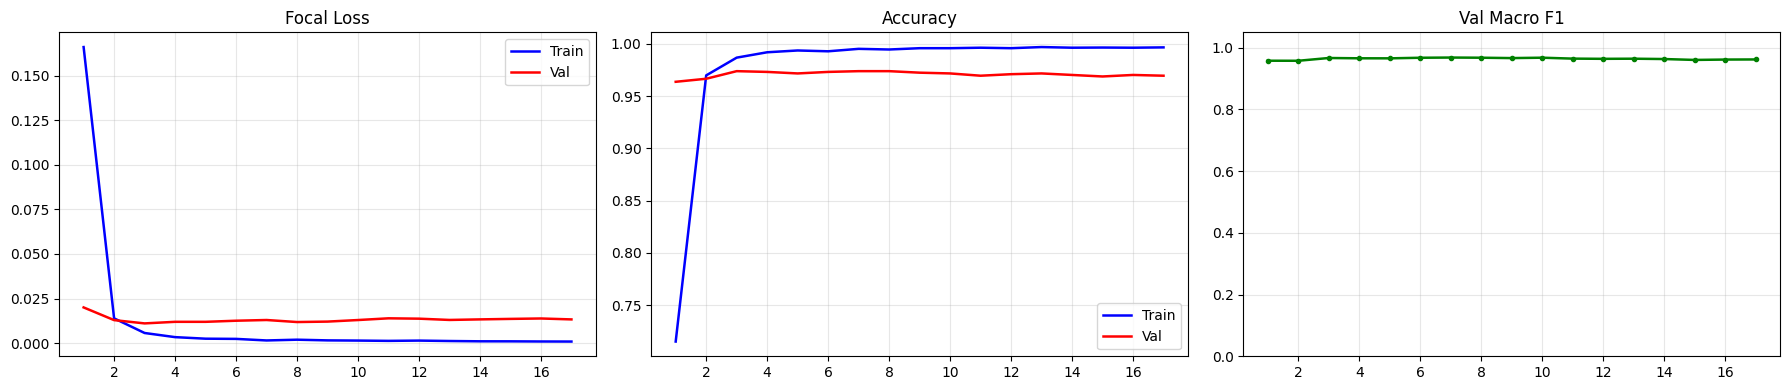

Best val_accuracy : 0.9738


In [23]:
loss     = history_clf.history.get("loss", [])
val_loss = history_clf.history.get("val_loss", [])
acc      = history_clf.history.get("accuracy", [])
val_acc  = history_clf.history.get("val_accuracy", [])
macro_f1 = per_cat_cb.history.get("macro_f1", [])
epochs   = range(1, len(loss) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, loss,     "b-", label="Train", linewidth=1.8)
axes[0].plot(epochs, val_loss, "r-", label="Val",   linewidth=1.8)
axes[0].set_title("Focal Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, acc,     "b-", label="Train", linewidth=1.8)
axes[1].plot(epochs, val_acc, "r-", label="Val",   linewidth=1.8)
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)

if macro_f1:
    ep2 = range(1, len(macro_f1) + 1)
    axes[2].plot(ep2, macro_f1, "g-o", markersize=3, linewidth=1.8)
    axes[2].set_title("Val Macro F1"); axes[2].set_ylim(0, 1.05); axes[2].grid(alpha=0.3)
    print(f"Best val_macro_f1 : {max(macro_f1):.4f}  (epoch {macro_f1.index(max(macro_f1)) + 1})")

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Best val_accuracy : {max(val_acc):.4f}")


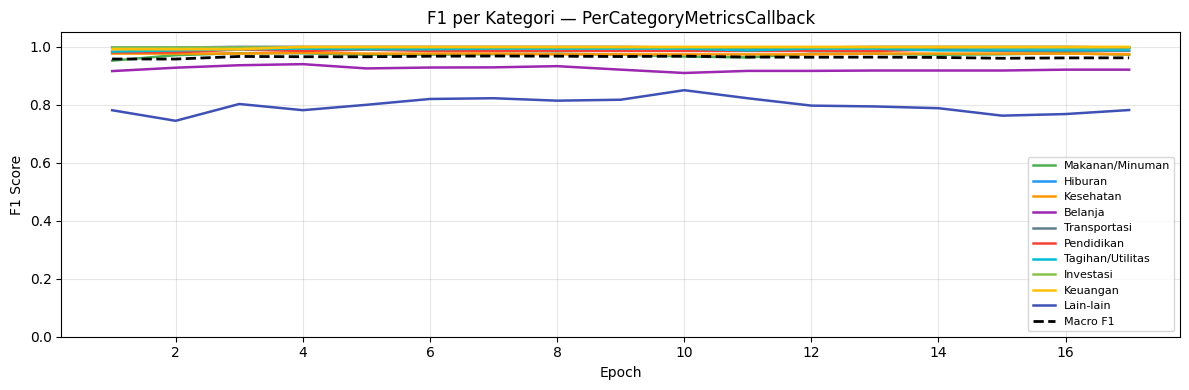

In [24]:
COLORS = ["#4CAF50","#2196F3","#FF9800","#9C27B0","#607D8B",
          "#F44336","#00BCD4","#8BC34A","#FFC107","#3F51B5"]

fig, ax = plt.subplots(figsize=(12, 4))
for cat, color in zip(config.CATEGORIES, COLORS):
    f1_hist = per_cat_cb.history.get(cat, [])
    if f1_hist:
        ax.plot(range(1, len(f1_hist)+1), f1_hist, label=cat, color=color, linewidth=1.8)
if macro_f1:
    ax.plot(range(1, len(macro_f1)+1), macro_f1, "k--", linewidth=2, label="Macro F1")

ax.set_xlabel("Epoch"); ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.05)
ax.set_title("F1 per Kategori — PerCategoryMetricsCallback")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/f1_per_category.png", dpi=120, bbox_inches="tight")
plt.show()


=== Classification Report (Test Set) ===
                  precision    recall  f1-score   support

 Makanan/Minuman       0.96      0.97      0.97       297
         Hiburan       1.00      1.00      1.00        56
       Kesehatan       1.00      0.97      0.98       175
         Belanja       0.98      0.91      0.94       130
    Transportasi       0.99      0.99      0.99       197
      Pendidikan       0.98      0.98      0.98       106
Tagihan/Utilitas       0.98      0.99      0.99       244
       Investasi       1.00      1.00      1.00        49
        Keuangan       1.00      1.00      1.00        58
       Lain-lain       0.73      0.86      0.79        64

        accuracy                           0.97      1376
       macro avg       0.96      0.97      0.96      1376
    weighted avg       0.97      0.97      0.97      1376



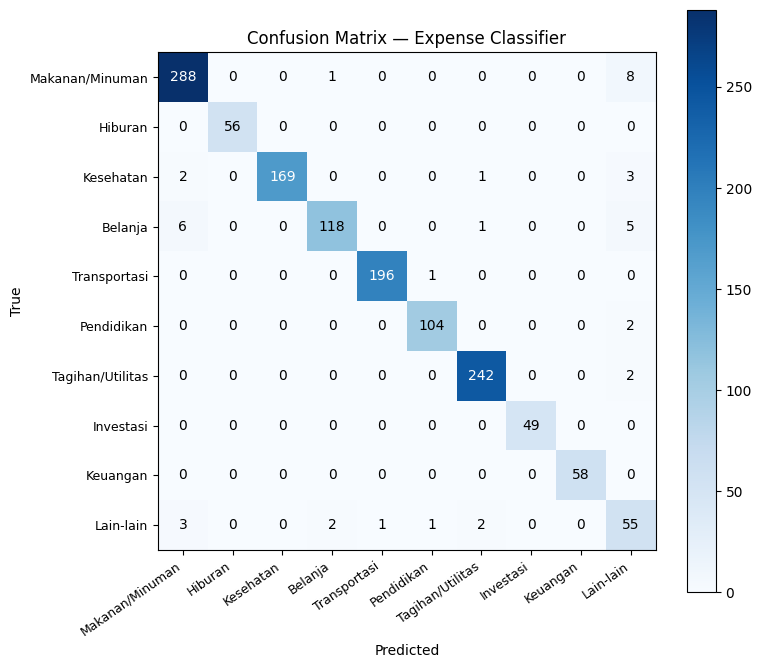

In [25]:
y_true_all, y_pred_all = [], []
for x_batch, y_batch in test_ds:
    probs = clf_model.predict(x_batch, verbose=0)
    y_pred_all.append(np.argmax(probs, axis=1))
    y_true_all.append(np.argmax(y_batch.numpy(), axis=1))

y_true = np.concatenate(y_true_all)
y_pred = np.concatenate(y_pred_all)

present_labels = sorted(np.unique(np.concatenate([y_true, y_pred])))
present_names  = [config.CATEGORIES[i] for i in present_labels]

print("=== Classification Report (Test Set) ===")
print(classification_report(y_true, y_pred,
                             labels=present_labels,
                             target_names=present_names))

cm  = confusion_matrix(y_true, y_pred, labels=present_labels)
fig, ax = plt.subplots(figsize=(8, 7))
im  = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(present_labels))); ax.set_yticks(range(len(present_labels)))
ax.set_xticklabels(present_names, rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(present_names, fontsize=9)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix — Expense Classifier")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=10)
plt.colorbar(im, ax=ax); plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. TensorBoard

```python
%load_ext tensorboard
%tensorboard --logdir /kaggle/working/tensorboard_logs
```

Atau dari terminal lokal setelah download log:
```bash
tensorboard --logdir ./tensorboard_logs
# Buka: http://localhost:6006
```

Metrics yang tersedia:
- `loss` / `val_loss` — Focal Loss per epoch
- `accuracy` / `val_accuracy`
- `val_macro_f1` — dari PerCategoryMetricsCallback
- `precision` / `recall`
- Histogram bobot (`histogram_freq=1`)
- Model graph


In [26]:
try:
    %load_ext tensorboard
    %tensorboard --logdir /kaggle/working/tensorboard_logs
except Exception as e:
    print(f"TensorBoard inline gagal: {e}")
    print(f"Jalankan manual: tensorboard --logdir {config.TB_LOG_DIR}")


<IPython.core.display.Javascript object>

## 6. Export — Production Artifacts

In [27]:
import zipfile, json as _json

Path("/kaggle/working/models").mkdir(parents=True, exist_ok=True)

# Simpan vectorizer vocab
vocab = vectorizer.get_vocabulary()
with open(str(config.VOCAB_PATH), "w", encoding="utf-8") as f:
    _json.dump(vocab, f, ensure_ascii=False)
print(f"Vocab    : {config.VOCAB_PATH}  ({len(vocab)} tokens)")

# Simpan model
clf_model.save(str(config.CLF_MODEL_PATH))
print(f"Classifier: {config.CLF_MODEL_PATH}")
print(f"  Params : {clf_model.count_params():,}")

# Test load
from custom_components import CUSTOM_OBJECTS
clf_reload = tf.keras.models.load_model(
    str(config.CLF_MODEL_PATH), custom_objects=CUSTOM_OBJECTS
)
print(f"Test load → {clf_reload.count_params():,} params — OK")
del clf_reload

# Zip artifacts
ZIP_PATH = "/kaggle/working/hematIn_artifacts.zip"
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for fp in Path("/kaggle/working/models").rglob("*"):
        if fp.is_file():
            zf.write(fp, fp.relative_to("/kaggle/working"))
    for png in Path("/kaggle/working").glob("*.png"):
        zf.write(png, png.name)
print(f"Artifacts : {ZIP_PATH}  ({Path(ZIP_PATH).stat().st_size / 1024**2:.1f} MB)")

# Zip TensorBoard logs
tb_path = Path("/kaggle/working/tensorboard_logs")
if tb_path.exists() and any(tb_path.iterdir()):
    import shutil
    shutil.make_archive("/kaggle/working/tensorboard_logs", "zip", str(tb_path))
    print("TensorBoard logs di-zip ke: /kaggle/working/tensorboard_logs.zip")


Vocab    : /kaggle/working/models/vectorizer_vocab.json  (1109 tokens)
Classifier: /kaggle/working/models/classifier.keras
  Params : 483,114
Test load → 483,114 params — OK
Artifacts : /kaggle/working/hematIn_artifacts.zip  (3.1 MB)
TensorBoard logs di-zip ke: /kaggle/working/tensorboard_logs.zip


## 7. Inferensi

### 7.1 Load Models

In [28]:
import config, tensorflow as tf
from pathlib import Path
from custom_components import CUSTOM_OBJECTS

clf_path = Path("/kaggle/working/models/classifier.keras")

if clf_path.exists():
    clf_model = tf.keras.models.load_model(
        str(clf_path), custom_objects=CUSTOM_OBJECTS
    )
    print(f"Classifier : {clf_model.count_params():,} params — OK")
else:
    print("[WARN] classifier.keras belum ada — jalankan training dulu")
    clf_model = None

try:
    from ocr_pipeline import get_ocr_engine
    ocr_engine = get_ocr_engine(lang="en", use_gpu=False)
except ImportError as e:
    print(f"[WARN] PaddleOCR tidak tersedia: {e}")
    ocr_engine = None


Classifier : 483,114 params — OK


In [29]:
with open("/kaggle/working/pipeline.py") as f:
    for i, line in enumerate(f, 1):
        if "text_input" in line:
            print(f"{i}: {line}", end="")

47:     text_input = tf.constant([[clf_text]], dtype=tf.string)
51:         {"text": text_input, "tabular": tab_input}, verbose=0


### 7.2 Demo Classifier — Input Teks Langsung

In [30]:
import importlib, sys, pipeline
importlib.reload(pipeline)
from pipeline import classify_receipt

Teks Input                             Kategori                Conf  Status
--------------------------------------------------------------------------------
  aqua 600ml indomie goreng            Makanan/Minuman        0.901  ✓
  laptop asus vivobook 14              Belanja                0.997  ✓
  tiket bioskop avengers               Lain-lain              0.509  ✓
  deterjen rinso 900g                  Belanja                0.821  ✓
  grab motor ojek online               Transportasi           0.896  ✓
  samsung galaxy a55 5g                Belanja                0.934  ✓


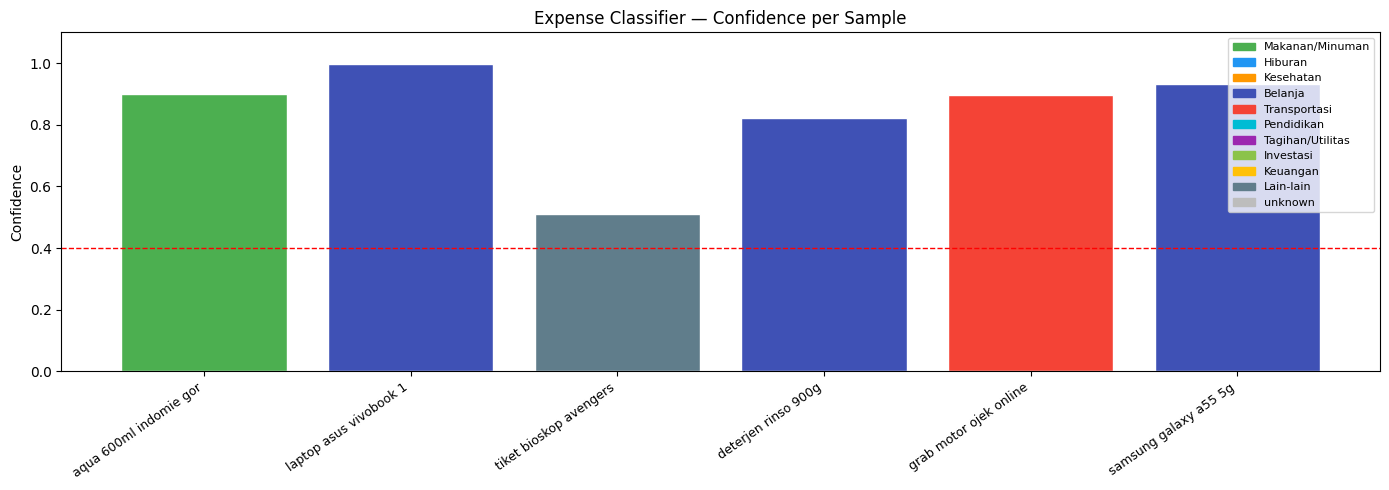

In [31]:
import matplotlib.patches as mpatches
from pipeline import classify_receipt
from config import clean_text, build_tabular_features, CATEGORIES, CONFIDENCE_THRESHOLD

TEST_CASES = [
    ("aqua 600ml indomie goreng",    8_500),
    ("laptop asus vivobook 14",  8_500_000),
    ("tiket bioskop avengers",      75_000),
    ("deterjen rinso 900g",         32_000),
    ("grab motor ojek online",      18_000),
    ("samsung galaxy a55 5g",    5_000_000),
]

CMAP = {
    "Makanan/Minuman" : "#4CAF50", "Hiburan"          : "#2196F3",
    "Kesehatan"       : "#FF9800", "Belanja"          : "#3F51B5",
    "Transportasi"    : "#F44336", "Pendidikan"       : "#00BCD4",
    "Tagihan/Utilitas": "#9C27B0", "Investasi"        : "#8BC34A",
    "Keuangan"        : "#FFC107", "Lain-lain"        : "#607D8B",
    "unknown"         : "#BDBDBD",
}

if clf_model is not None:
    results = []
    print(f"{'Teks Input':<38} {'Kategori':<22} {'Conf':>5}  Status")
    print("-" * 80)
    for text, total in TEST_CASES:
        r = classify_receipt(clean_text(text),
                             build_tabular_features(total).tolist(),
                             clf_model)
        results.append((text, r))
        flag = "✓" if r["is_confident"] else "⚠ low"
        print(f"  {text:<36} {r['category']:<22} {r['confidence']:.3f}  {flag}")

    fig, ax = plt.subplots(figsize=(14, 5))
    confs  = [r[1]["confidence"] for r in results]
    cats   = [r[1]["category"]   for r in results]
    colors = [CMAP.get(c, "#999") for c in cats]
    ax.bar(range(len(results)), confs, color=colors, edgecolor="white")
    ax.axhline(CONFIDENCE_THRESHOLD, color="red", linestyle="--", linewidth=1,
               label=f"threshold={CONFIDENCE_THRESHOLD}")
    ax.set_xticks(range(len(results)))
    ax.set_xticklabels([r[0][:22] for r in results], rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Confidence"); ax.set_ylim(0, 1.1)
    ax.set_title("Expense Classifier — Confidence per Sample")
    legend = [mpatches.Patch(color=v, label=k) for k, v in CMAP.items()]
    ax.legend(handles=legend, loc="upper right", fontsize=8)
    plt.tight_layout(); plt.show()


### 7.3 Demo Full Pipeline — Gambar Struk → JSON

Demo: receipt_00081.png


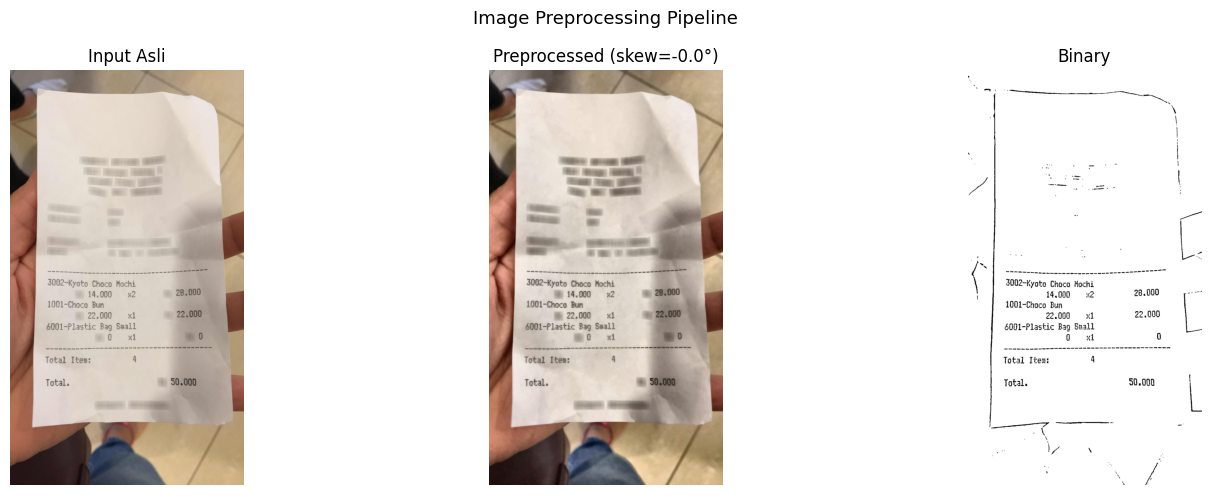


=== PaddleOCR ===
Baris terdeteksi: 14
  [ 1] conf=0.74  5
  [ 2] conf=0.92  2
  [ 3] conf=0.70  J0o2-Kyoto Choco Mochi
  [ 4] conf=0.90  28.000
  [ 5] conf=0.93  14.000
  [ 6] conf=0.89  1001-Choco Bun
  [ 7] conf=0.73  22 .000
  [ 8] conf=0.61  22 .000
  [ 9] conf=0.99  6001-Plastic
  [10] conf=0.98  Bag
  [11] conf=1.00  Total
  [12] conf=0.82  Item:
  [13] conf=0.63  50.000
  [14] conf=0.88  Total.


In [32]:
import cv2, random, json
from pathlib import Path
from image_preprocessing import preprocess_image
from ocr_pipeline import run_ocr, ocr_to_lines
from receipt_parser import extract_fields
from pipeline import classify_receipt

# Cari gambar demo dari CORD
DEMO_PATH = None
for search_dir in [config.CORD_DIR / "test" / "image",
                   config.CORD_DIR / "dev"  / "image"]:
    imgs = sorted(Path(search_dir).glob("*.png")) if Path(search_dir).exists() else []
    if imgs:
        random.seed(42)
        DEMO_PATH = random.choice(imgs)
        break

if DEMO_PATH is None:
    print("[WARN] Tidak ada gambar CORD — menggunakan raw_lines dummy")
    raw_lines = [
        "WARTEG BAHARI",
        "Nasi Goreng Spesial  1 x 25000  25000",
        "Es Teh Manis         2 x 5000   10000",
        "Kerupuk              1 x 3000    3000",
        "TOTAL                            38000",
    ]
    prep = None
else:
    print(f"Demo: {DEMO_PATH.name}")
    prep = preprocess_image(DEMO_PATH, deskew=True)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    orig = cv2.imread(str(DEMO_PATH), cv2.IMREAD_COLOR)
    axes[0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Input Asli"); axes[0].axis("off")
    axes[1].imshow(cv2.cvtColor(prep["bgr"], cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Preprocessed (skew={prep['skew']:.1f}°)"); axes[1].axis("off")
    axes[2].imshow(prep["binary"], cmap="gray")
    axes[2].set_title("Binary"); axes[2].axis("off")
    plt.suptitle("Image Preprocessing Pipeline", fontsize=13)
    plt.tight_layout(); plt.show()

    if ocr_engine is not None:
        print("\n=== PaddleOCR ===")
        ocr_res   = run_ocr(prep["bgr"], ocr_engine)
        raw_lines = ocr_to_lines(ocr_res)
        print(f"Baris terdeteksi: {len(raw_lines)}")
        for i, (line, res) in enumerate(zip(raw_lines[:15], ocr_res[:15])):
            print(f"  [{i+1:2d}] conf={res['confidence']:.2f}  {line}")
    else:
        raw_lines = ["Tidak ada OCR engine"]


In [33]:
if raw_lines:
    fields = extract_fields(raw_lines)

    print("=== Field Extraction ===")
    print(f"  distinct_item_count : {fields['distinct_item_count']}")
    print(f"  total_qty           : {fields['total_qty']}")
    print(f"  total_expense       : Rp {fields['total_expense']:,.0f}")
    print(f"  avg_item_price      : Rp {fields['avg_item_price']:,.0f}")
    print(f"  clf_text            : '{fields['clf_text']}'")

    if fields["items"]:
        print(f"\n  {'Item':<30} {'Qty':>4} {'Unit Price':>12} {'Line Total':>12}")
        print("  " + "-" * 62)
        for it in fields["items"]:
            print(f"  {it['name']:<30} {it['qty']:>4} "
                  f"Rp{it['unit_price']:>10,.0f} Rp{it['line_total']:>10,.0f}")

    if clf_model is not None:
        clf_result = classify_receipt(
            clf_text     = fields["clf_text"],
            tab_features = fields["tab_features"],
            clf_model    = clf_model,
        )
        print(f"\n=== Klasifikasi ===")
        print(f"  Kategori   : {clf_result['category']}")
        conf_flag = "✓ Confident" if clf_result["is_confident"] else f"⚠ Low (threshold={config.CONFIDENCE_THRESHOLD})"
        print(f"  Confidence : {clf_result['confidence']:.4f}  {conf_flag}")
        print("\n  Semua probabilitas:")
        for cat, prob in sorted(clf_result["all_probs"].items(), key=lambda x: -x[1]):
            bar = "█" * int(prob * 30)
            print(f"  {cat:<28} {prob:.4f}  {bar}")

        output_json = {
            "items"       : fields["items"],
            "total"       : fields["total_expense"],
            "category"    : clf_result["category"],
            "confidence"  : clf_result["confidence"],
            "is_confident": clf_result["is_confident"],
        }
        print("\n=== JSON Output (FastAPI-ready) ===")
        print(json.dumps(output_json, indent=2, ensure_ascii=False))


=== Field Extraction ===
  distinct_item_count : 2
  total_qty           : 2
  total_expense       : Rp 50,000
  avg_item_price      : Rp 25,000
  clf_text            : 'kyoto choco mochi choco bun'

  Item                            Qty   Unit Price   Line Total
  --------------------------------------------------------------
  Kyoto Choco Mochi                 1 Rp    28,000 Rp    28,000
  Choco Bun                         1 Rp    22,000 Rp    22,000

=== Klasifikasi ===
  Kategori   : unknown
  Confidence : 0.2832  ⚠ Low (threshold=0.4)

  Semua probabilitas:
  Lain-lain                    0.2832  ████████
  Makanan/Minuman              0.2725  ████████
  Belanja                      0.2203  ██████
  Tagihan/Utilitas             0.0990  ██
  Pendidikan                   0.0433  █
  Kesehatan                    0.0383  █
  Transportasi                 0.0227  
  Keuangan                     0.0163  
  Investasi                    0.0024  
  Hiburan                      0.0020  

=== 

In [34]:
print(df_all["kategori"].value_counts())
print(f"\nTotal: {len(df_all)}")

kategori
Makanan/Minuman     1981
Tagihan/Utilitas    1623
Transportasi        1316
Kesehatan           1165
Belanja              865
Pendidikan           703
Lain-lain            423
Keuangan             391
Hiburan              373
Investasi            331
Name: count, dtype: int64

Total: 9171


In [35]:
print(f"Best val_accuracy : {max(history_clf.history['val_accuracy']):.4f}")
print(f"Best val_macro_f1 : {max(per_cat_cb.history['macro_f1']):.4f}")
print(f"Stopped at epoch  : {len(history_clf.history['loss'])}")

Best val_accuracy : 0.9738
Best val_macro_f1 : 0.9683
Stopped at epoch  : 17


In [36]:
import numpy as np
final_loss = history_clf.history['loss'][-1]
final_val  = history_clf.history['val_loss'][-1]
print(f"Final train loss : {final_loss:.4f}")
print(f"Final val loss   : {final_val:.4f}")

Final train loss : 0.0008
Final val loss   : 0.0133


In [37]:
for cat in ["Makanan/Minuman", "Transportasi", "Lain-lain"]:
    samples = df_all[df_all["kategori"] == cat]["clean_text"].sample(
        min(5, len(df_all[df_all["kategori"] == cat])), random_state=42
    ).tolist()
    print(f"\n[{cat}]")
    for s in samples:
        print(f"  {s}")


[Makanan/Minuman]
  vegetables
  restaurant dinner
  lunch
  restaurant dinner
  coffee

[Transportasi]
  current residence to place 1 bus stop highway
  train ticket
  uber ride
  place 4 to place 0
  current residence to place 1 bus stop highway

[Lain-lain]
  mutual fund c
  ganpati navratri vargani
  vargini
  hair cut
  11 clothes ironing
